In [1]:
from nichenetpy.utils import read_csv_cols
from nichenetpy.gene_symbol import mouse_alias_info
from nichenetpy.extraction import subset_ann
from nichenetpy.metrics import group_metrics

import pandas as pd
import scanpy as sc
import anndata
import matplotlib.pyplot as plt

get the AnnData object

In [2]:
ann = anndata.io.read_h5ad("D:/Data/nichenetpy/annData/annData3531889.h5")
ann.var_names = ann.var["gene"]
mouse_alias_info.alias_to_symbol(ann)

get the seuratv5 DE_table

In [3]:
data = read_csv_cols("D:/Data/nichenetpy/other/DE_table_seuratv5.csv")
DE_table_seurat = pd.DataFrame({
    "gene": data["gene"],
    "lfc": [float(x) for x in data["avg_log2FC"]],
    "pval": [float(x) for x in data["p_val"]],
    "pval_adj": [float(x) for x in data["p_val_adj"]]
})
DE_table_seurat.index = DE_table_seurat["gene"]
DE_table_seurat.drop(columns={"gene"}, inplace=True)

compute the scanpy DE_table

In [4]:
ann_receiver = subset_ann(ann, "CD8 T", layers=["data"])
sc.tl.rank_genes_groups(
    ann_receiver,
    groupby="aggregate",
    method="wilcoxon",
    layer="data",
    groups=["LCMV"], 
    reference="SS"
)
res = ann_receiver.uns["rank_genes_groups"]
DE_table_scanpy = pd.DataFrame({
    "gene": [x[0] for x in res["names"]],
    "lfc": [x[0] for x in res["logfoldchanges"]],
    "pval": [x[0] for x in res["pvals"]],
    "pval_adj": [x[0] for x in res["pvals_adj"]]
})
DE_table_scanpy.index = DE_table_scanpy["gene"]
DE_table_scanpy.drop(columns={"gene"}, inplace=True)

compute the custom DE_table

In [5]:
pd.options.mode.chained_assignment = None # false positive warnings removal
group_metrics(
    ann_receiver,
    groupby="aggregate",
    layer="data",
    min_abs_lfc=0.25,
    min_pct=0.05
)
DE_table_custom = ann_receiver.uns["group_metrics"]
DE_table_custom = DE_table_custom[DE_table_custom["aggregate"] == "LCMV"]
DE_table_custom.index = DE_table_custom["gene"]
DE_table_custom.drop(columns={"gene", "aggregate", "pct"}, inplace=True)
DE_table_custom.drop_duplicates(inplace=True)

In [6]:
geneset_seurat = set(DE_table_seurat[(abs(DE_table_seurat["lfc"]) >= 0.25) & (DE_table_seurat["pval_adj"] <= 0.05)].index)
len(geneset_seurat)

322

In [7]:
geneset_scanpy = set(DE_table_scanpy[(abs(DE_table_scanpy["lfc"]) >= 0.25) & (DE_table_scanpy["pval_adj"] <= 0.05)].index)
len(geneset_scanpy)

322

In [8]:
geneset_custom = set(DE_table_custom[
    (DE_table_custom["pval_adj"] <= 0.05)
].index)
len(geneset_custom)

322

Seurat and scanpy genesets have same size by coincidence... They are not the same

In [9]:
len(geneset_seurat.intersection(geneset_scanpy))

268

Seurat and custom yield identical genesets

In [10]:
len(geneset_seurat.intersection(geneset_custom))

322

combine the tables

In [11]:
DE_table_custom.rename(
    columns=lambda x : f"{x}_custom",
    inplace=True
)
DE_table = DE_table_seurat.join(
    DE_table_scanpy,
    how="inner",
    lsuffix="_seurat",
    rsuffix="_scanpy"
).join(DE_table_custom, how="inner")

In [12]:
len(DE_table)

2632

In [13]:
def plot_diff(
    xs,
    ys,
    title,
    xlabel,
    ylabel,
    figsize=(5, 5),
    axis_range=None
):
    figsize = (5, 5)
    min_x = min(xs)
    max_x = max(xs)
    min_y = min(ys)
    max_y = max(ys)
    mn = min(min_x, min_y)
    mx = max(max_x, max_y)
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(xs, ys, "b.", markersize=1)
    ax.set_aspect('equal', adjustable='box')
    ax.plot((mn, mx), (mn, mx), "r-")
    if axis_range is not None:
        ax.set_xlim(-axis_range, axis_range)
        ax.set_ylim(ax.get_xlim())
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    return (fig, ax)

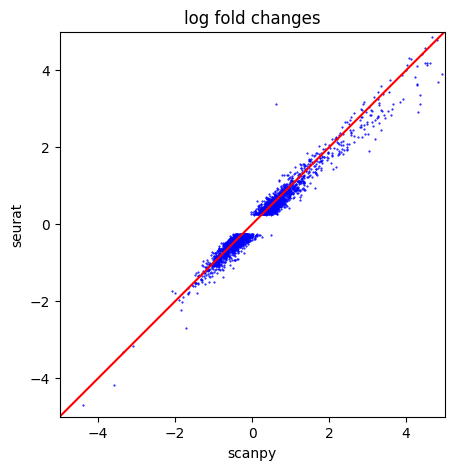

In [14]:
fig, ax = plot_diff(
    DE_table["lfc_scanpy"],
    DE_table["lfc_seurat"],
    title="log fold changes",
    xlabel="scanpy",
    ylabel="seurat",
    axis_range=5
)
plt.show()

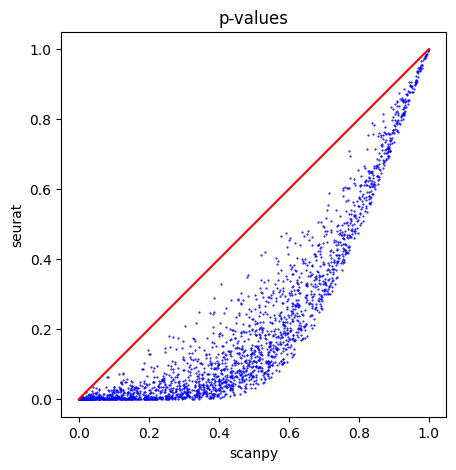

In [15]:
fig, ax = plot_diff(
    DE_table["pval_scanpy"],
    DE_table["pval_seurat"],
    title="p-values",
    xlabel="scanpy",
    ylabel="seurat"
)
plt.show()

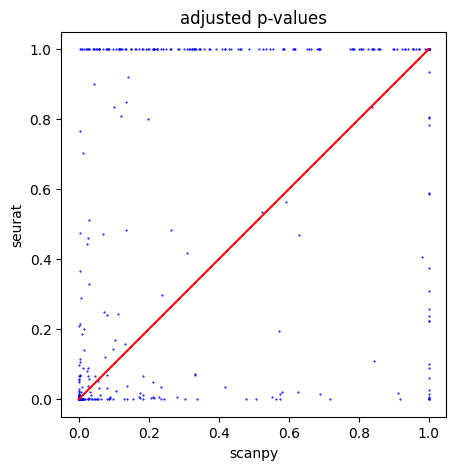

In [16]:
fig, ax = plot_diff(
    DE_table["pval_adj_scanpy"],
    DE_table["pval_adj_seurat"],
    title="adjusted p-values",
    xlabel="scanpy",
    ylabel="seurat"
)
plt.show()

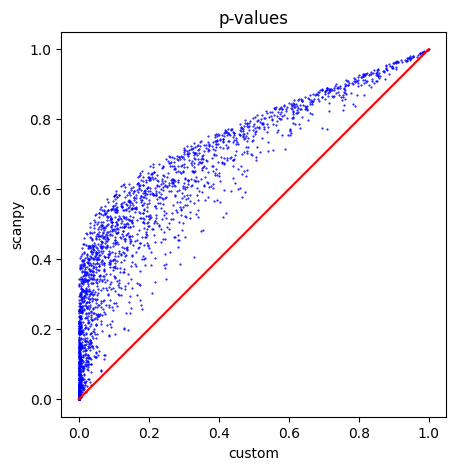

In [17]:
fig, ax = plot_diff(
    DE_table["pval_custom"],
    DE_table["pval_scanpy"],
    title="p-values",
    xlabel="custom",
    ylabel="scanpy"
)
plt.show()

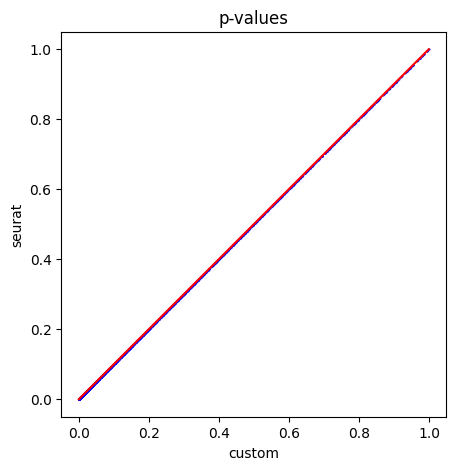

In [18]:
fig, ax = plot_diff(
    DE_table["pval_custom"],
    DE_table["pval_seurat"],
    title="p-values",
    xlabel="custom",
    ylabel="seurat"
)
plt.show()

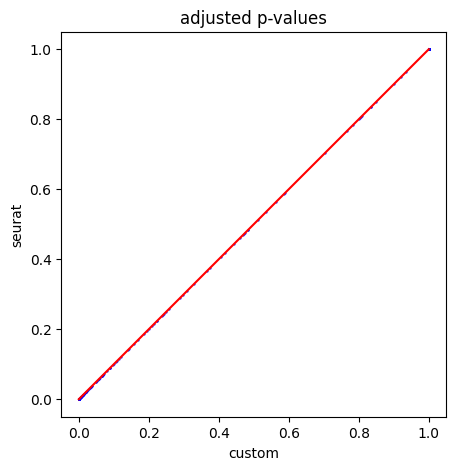

In [19]:
fig, ax = plot_diff(
    DE_table["pval_adj_custom"],
    DE_table["pval_adj_seurat"],
    title="adjusted p-values",
    xlabel="custom",
    ylabel="seurat"
)
plt.show()

In [20]:
(DE_table["lfc_custom"] - DE_table["lfc_seurat"]).sort_values(ascending=False)

gene
Alb       3.907985e-14
Tmbim6    6.661338e-15
Gm6907    6.217249e-15
Ms4a6d    5.773160e-15
Ly6c2     5.773160e-15
              ...     
Adar     -5.329071e-15
Gzma     -5.329071e-15
Ogfrl1   -5.329071e-15
Jak2     -5.773160e-15
Apoa2    -3.375078e-14
Length: 2632, dtype: float64

In [21]:
(DE_table["pval_adj_custom"] - DE_table["pval_adj_seurat"]).sort_values(ascending=False)

gene
Gm5921     1.887379e-15
Vps54      1.332268e-15
Dbnl       1.221245e-15
Gm10837    1.221245e-15
Seh1l      1.110223e-15
               ...     
Anp32b    -2.220446e-16
Chmp4b    -2.220446e-16
Pla2g16   -3.053113e-16
Ahnak     -3.330669e-16
Gm8692    -4.440892e-16
Length: 2632, dtype: float64

In [22]:
DE_table[["pval_seurat", "pval_custom"]]

,pval_seurat,pval_custom
gene,,
Ifi27l2b,2.164082e-150,2.164082e-150
Irf7,5.425060e-129,5.425060e-129
Ly6a,8.023340e-124,8.023340e-124
Ifi27l2a,2.882324e-115,2.882324e-115
Stat1,2.742811e-92,2.742811e-92
...,...,...
1810058I24Rik,9.857545e-01,9.857545e-01
Gorasp2,9.935187e-01,9.935187e-01
Atp6ap1,9.952077e-01,9.952077e-01


In [23]:
from nichenetpy.network import LigandReceptorNetwork, WeightedNetwork
from nichenetpy.wrappers import generate_info_tables, run_nichenet
from nichenetpy.prediction import LigandActivityPredictor
from nichenetpy.utils import read_matrix_from_csv
data = read_csv_cols("D:/Data/nichenetpy/other/sender_receiver_de_seurat.csv")
sender_receiver_de_seurat = pd.DataFrame(data)
mouse_alias_info.alias_to_symbol(ann)
predictor = LigandActivityPredictor(*read_matrix_from_csv("D:/Data/nichenetpy/model/mouse/csv/ligand_target_matrix_mouse.csv"))
lr_network = LigandReceptorNetwork(filename="D:/Data/nichenetpy/model/mouse/csv/lr_network_mouse.csv")
lr_sig = WeightedNetwork(filename="D:/Data/nichenetpy/model/mouse/csv/lr_sig_mouse.csv")
res = run_nichenet(
    ann,
    predictor,
    lr_network,
    "CD8 T",
    "LCMV",
    "SS",
    sender_celltypes=("CD4 T", "Treg", "Mono", "NK", "B", "DC"),
)
ligand_activities_sorted = res["ligand_activities_sorted_focused"]
best_upstream_ligands = res["best_upstream_ligands_focused"]
expressed_ligands = res["expressed_ligands"]
expressed_receptors = res["expressed_receptors"]
sender_receiver_de_custom = generate_info_tables(
    ann,
    "celltype",
    ("CD4 T", "Treg", "Mono", "NK", "B", "DC"),
    ["CD8 T"],
    lr_network.subset_sep(expressed_ligands, expressed_receptors),
    "aggregate",
    "LCMV",
    "SS",
    case_control=True
)["sender_receiver_de"]

ValueError: x and y must have same first dimension, but have shapes (1230,) and (1212,)

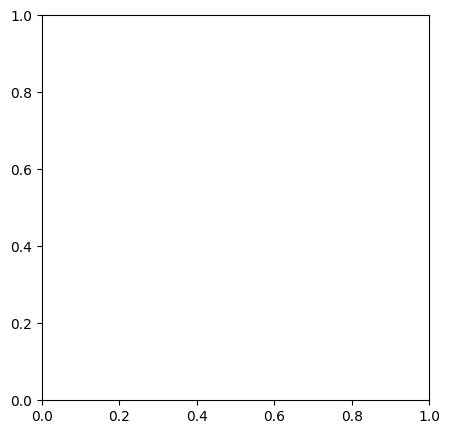

In [26]:
fig, ax = plot_diff(
    sender_receiver_de_custom["pval_adj_ligand"],
    [float(e) for e in sender_receiver_de_seurat["p_adj_ligand"]],
    title="p-values",
    xlabel="custom",
    ylabel="seurat"
)
plt.show()